# 第 13 章　訓練深度網路的實戰技巧與遷移學習 — 實作 Notebook

「醫學生的機器學習入門」第 13 章配套程式（網站：<https://med-study-rpg.com/ml/chapters/13-transfer-learning/>）。建議在 **Google Colab** 執行（「執行階段 → 全部執行」）；本機 Jupyter 需安裝 `tensorflow` 與 `keras`。

本 notebook 用 **BreastMNIST 128×128**（乳房超音波，良性／惡性，訓練集只有 546 張）做三方對照：

1. 從零訓練的小 CNN（看過擬合）
2. 小 CNN ＋ 資料擴增 ＋ Dropout ＋ `class_weight` ＋ callbacks
3. 遷移學習：ImageNet 預訓練的 MobileNetV2 ——（3a）凍結當特徵擷取器、（3b）微調最後一個區塊
4. 最後用 Grad-CAM 看模型「看哪裡」，並做一個簡單的健全性檢查（sanity check）

全部跑完在筆電 CPU 上約 1.5–2 分鐘，Colab 免費 CPU 會更久（預估數分鐘）；第 2、4 節從零訓練 CNN 最花時間，**可開 GPU（執行階段 → 變更執行階段類型）加速**。

本 notebook 的醫學資料為公開教學資料集，結果僅供學習，不構成臨床建議。

## 0. 環境檢查
先印出套件版本。Keras 3 要在 `import keras` **之前**設定 backend。沒有安裝 Keras 的環境會印出提示，後面需要 Keras 的段落會自動跳過。

In [1]:
import os
import time
os.environ["KERAS_BACKEND"] = "tensorflow"   # must be set before importing keras

import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("numpy", np.__version__, "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)

try:
    import keras
    import tensorflow as tf
    print("keras", keras.__version__, "| tensorflow", tf.__version__, "| backend:", keras.backend.backend())
except ImportError:
    keras = None
    tf = None
    print("Keras/TensorFlow is not installed -> the deep-learning cells will be skipped.")
    print("Run this notebook on Google Colab, or `pip install tensorflow keras` locally.")

RS = 42
T0 = time.time()

numpy 2.1.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


keras 3.13.2 | tensorflow 2.20.0 | backend: tensorflow


## 1. 載入 BreastMNIST 128×128
直接從 Zenodo 下載 MedMNIST 官方的 `.npz`（約 11 MB，授權 CC BY 4.0），不需要安裝 `medmnist`。原始標籤 **0 = 惡性、1 = 正常／良性**；為了讓「惡性」當陽性，我們把它翻成 `y = 1 - label`。

In [2]:
import urllib.request

NPZ_URL = "https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1"
NPZ_PATH = os.path.join("data", "breastmnist_128.npz")
os.makedirs("data", exist_ok=True)

data = None
try:
    if not os.path.exists(NPZ_PATH):
        print("downloading BreastMNIST 128x128 (~11 MB) from Zenodo ...")
        urllib.request.urlretrieve(NPZ_URL, NPZ_PATH)
    data = np.load(NPZ_PATH)
except Exception as e:
    print("Could not download/load BreastMNIST:", repr(e))
    print("Check your internet connection or download the file manually from", NPZ_URL)

if data is not None:
    X_tr, X_va, X_te = (data[f"{s}_images"] for s in ["train", "val", "test"])
    # original labels: 0 = malignant, 1 = normal/benign  ->  y = 1 means malignant
    y_tr, y_va, y_te = (1 - data[f"{s}_labels"].ravel().astype("int64") for s in ["train", "val", "test"])
    for name, X_, y_ in [("train", X_tr, y_tr), ("val", X_va, y_va), ("test", X_te, y_te)]:
        print(f"{name:5s} {X_.shape}  malignant={y_.sum():3d}  benign/normal={(y_ == 0).sum():3d}")

train (546, 128, 128)  malignant=147  benign/normal=399
val   (78, 128, 128)  malignant= 21  benign/normal= 57
test  (156, 128, 128)  malignant= 42  benign/normal=114


先看幾張影像。超音波的上方是靠近探頭的皮膚與淺層組織，下方是深層，這個「上下」有解剖意義，等一下講資料擴增時會用到。

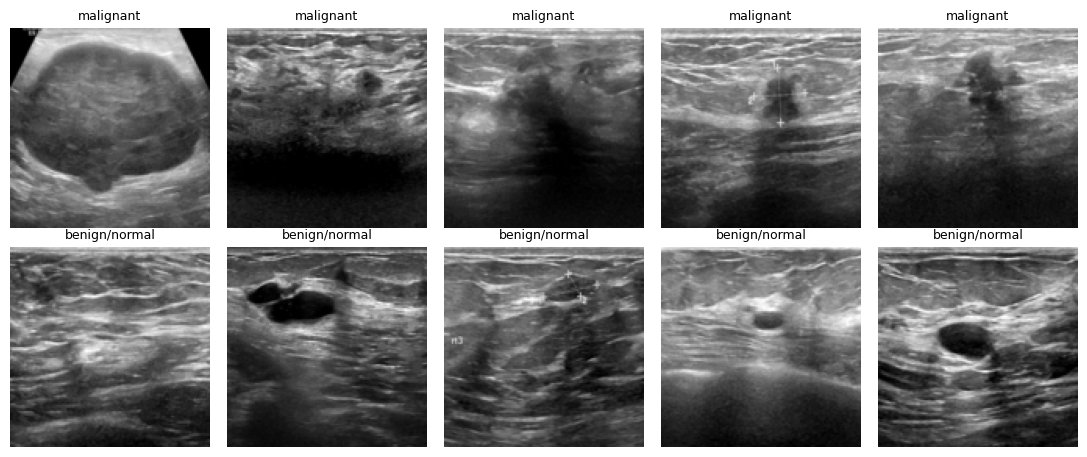

In [3]:
if data is not None:
    fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
    idx_m = np.where(y_tr == 1)[0][:5]
    idx_b = np.where(y_tr == 0)[0][:5]
    for ax, i in zip(axes.ravel(), np.concatenate([idx_m, idx_b])):
        ax.imshow(X_tr[i], cmap="gray")
        ax.set_title("malignant" if y_tr[i] == 1 else "benign/normal", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

接著準備共用的小工具：

- 小 CNN 的輸入：為了在 CPU 上省時間，把 128×128 用 2×2 平均**縮小成 64×64**，除以 255 縮放到 0～1，形狀 `(N, 64, 64, 1)`。遷移學習的部分則用完整的 128×128。
- 評估函式：印出測試集 AUC（附 bootstrap 95% 信賴區間）、敏感度、特異度。**測試集只有 156 張（惡性 42 張）**，信賴區間會很寬，請一起看。

In [4]:
from sklearn.metrics import roc_auc_score, confusion_matrix

def bootstrap_auc_ci(y_true, score, n_boot=1000, seed=RS):
    rng = np.random.default_rng(seed)
    n, aucs = len(y_true), []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if y_true[idx].min() == y_true[idx].max():
            continue                      # resample has only one class
        aucs.append(roc_auc_score(y_true[idx], score[idx]))
    return np.percentile(aucs, [2.5, 97.5])

results = {}

def report(name, y_true, score, threshold=0.5):
    auc = roc_auc_score(y_true, score)
    lo, hi = bootstrap_auc_ci(y_true, score)
    tn, fp, fn, tp = confusion_matrix(y_true, (score >= threshold).astype(int)).ravel()
    sens, spec = tp / (tp + fn), tn / (tn + fp)
    results[name] = dict(auc=auc, lo=lo, hi=hi, sens=sens, spec=spec)
    print(f"{name}: test AUC {auc:.3f} (95% CI {lo:.3f}-{hi:.3f}) | "
          f"sensitivity {sens:.2f} | specificity {spec:.2f}  (threshold {threshold})")

def batched(model, X_, bs=64):
    # predict in batches by calling the model directly (inference mode)
    return np.concatenate([np.asarray(model(X_[i:i + bs], training=False)) for i in range(0, len(X_), bs)])

def to_gray64(X_):
    # 128x128 -> 64x64 by averaging 2x2 blocks, scaled to 0-1
    return X_.reshape(-1, 64, 2, 64, 2).mean(axis=(2, 4))[..., None].astype("float32") / 255.0

if data is not None:
    Xg_tr, Xg_va, Xg_te = to_gray64(X_tr), to_gray64(X_va), to_gray64(X_te)
    print("small-CNN input shape:", Xg_tr.shape)

small-CNN input shape: (546, 64, 64, 1)


## 2. 基準 A：從零訓練一個小 CNN
沿用第 12 章的卷積＋池化結構，最後用 `Flatten` 接全連接層。這個模型有二十多萬個參數，卻只有 546 張訓練影像——我們故意**不加早停**、跑滿 20 個 epoch，觀察過擬合。

In [5]:
def small_cnn(augment=False, batchnorm=False, dropout=0.0):
    layers = [keras.Input(shape=(64, 64, 1))]
    if augment:
        layers += [keras.layers.RandomFlip("horizontal"),     # left-right flip only
                   keras.layers.RandomRotation(0.05),           # about +/- 18 degrees
                   keras.layers.RandomZoom(0.1)]
    for filters in (16, 32, 64):
        layers.append(keras.layers.Conv2D(filters, 3, padding="same", use_bias=not batchnorm))
        if batchnorm:
            layers.append(keras.layers.BatchNormalization())
        layers += [keras.layers.Activation("relu"), keras.layers.MaxPooling2D()]
    layers += [keras.layers.Flatten(), keras.layers.Dropout(dropout),
               keras.layers.Dense(64, activation="relu"),
               keras.layers.Dense(1, activation="sigmoid")]
    return keras.Sequential(layers)

hist_a = None
if keras is not None and data is not None:
    keras.utils.set_random_seed(RS)
    model_a = small_cnn()
    model_a.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                    loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    print("parameters:", f"{model_a.count_params():,}")
    t = time.time()
    hist_a = model_a.fit(Xg_tr, y_tr, validation_data=(Xg_va, y_va),
                         epochs=20, batch_size=32, verbose=0)
    print(f"training time: {time.time() - t:.1f} s")
    report("A: CNN from scratch", y_te, batched(model_a, Xg_te).ravel())
else:
    print("Skipped: Keras or the dataset is not available.")

parameters: 285,569


training time: 21.4 s


A: CNN from scratch: test AUC 0.888 (95% CI 0.829-0.939) | sensitivity 0.52 | specificity 0.95  (threshold 0.5)


畫出訓練與驗證的損失曲線：訓練損失一路往下，驗證損失卻在某個時間點後停滯甚至回升，這就是背答案的訊號。

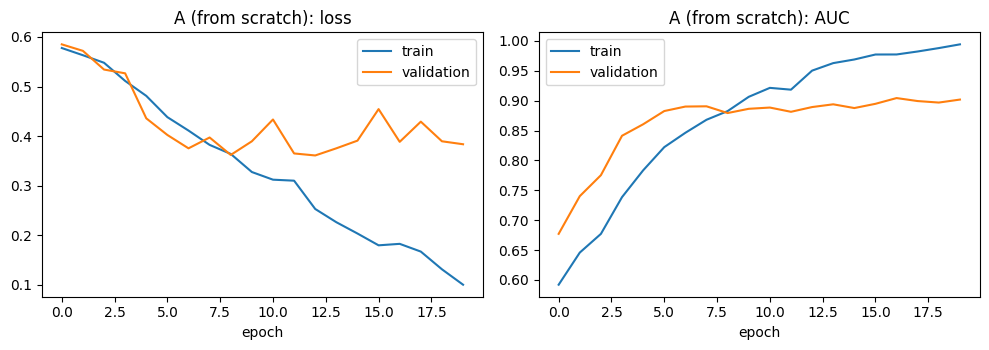

lowest validation loss at epoch 13; final train loss 0.100 vs validation loss 0.384


In [6]:
def plot_history(hist, title):
    h = hist.history
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="validation")
    axes[0].set_title(f"{title}: loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(h["auc"], label="train"); axes[1].plot(h["val_auc"], label="validation")
    axes[1].set_title(f"{title}: AUC"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()

if hist_a is not None:
    plot_history(hist_a, "A (from scratch)")
    best = int(np.argmin(hist_a.history["val_loss"]))
    print(f"lowest validation loss at epoch {best + 1}; final train loss "
          f"{hist_a.history['loss'][-1]:.3f} vs validation loss {hist_a.history['val_loss'][-1]:.3f}")

## 3. 學習率與最佳化器：一個不用神經網路的小實驗
在加入各種技巧之前，先用 NumPy 在一個「狹長山谷」形狀的損失函數上，比較三種最佳化器（optimizer）。這個山谷在一個方向很陡、另一個方向很平，是深度網路損失地形的常見縮影。

In [7]:
def loss_fn(w):                       # elongated bowl: steep in w[1], flat in w[0]
    return 0.5 * (0.1 * w[0] ** 2 + 10 * w[1] ** 2)

def grad_fn(w):
    return np.array([0.1 * w[0], 10 * w[1]])

def run(method, lr, steps=100):
    w, v, m, s = np.array([-8.0, 1.5]), np.zeros(2), np.zeros(2), np.zeros(2)
    for t in range(1, steps + 1):
        g = grad_fn(w)
        if method == "sgd":
            w = w - lr * g
        elif method == "momentum":
            v = 0.9 * v + g
            w = w - lr * v
        elif method == "adam":
            m = 0.9 * m + 0.1 * g
            s = 0.999 * s + 0.001 * g ** 2
            m_hat, s_hat = m / (1 - 0.9 ** t), s / (1 - 0.999 ** t)
            w = w - lr * m_hat / (np.sqrt(s_hat) + 1e-8)
    return loss_fn(w)

for method, lr in [("sgd", 0.01), ("sgd", 0.15), ("sgd", 0.21), ("momentum", 0.01), ("adam", 0.3)]:
    print(f"{method:8s} learning_rate={lr:<5} -> loss after 100 steps: {run(method, lr):.4g}")

sgd      learning_rate=0.01  -> loss after 100 steps: 2.62
sgd      learning_rate=0.15  -> loss after 100 steps: 0.1557
sgd      learning_rate=0.21  -> loss after 100 steps: 2.136e+09
momentum learning_rate=0.01  -> loss after 100 steps: 0.435
adam     learning_rate=0.3   -> loss after 100 steps: 0.0002459


解讀：純 SGD 學習率太小（0.01）時，在平坦方向幾乎走不動；調大到 0.15 平坦方向進步了，但再大一點點（0.21）就在陡峭方向來回彈跳、損失爆掉。動量（momentum）把過去的方向累積起來，在平坦方向越走越快；Adam 則替每個參數各自調整步伐。**實務上 Adam（`learning_rate=1e-3`）是很好的起點**，微調預訓練模型時再把學習率降到 1e-4～1e-5。

在 Keras 裡只是換一個物件：

In [8]:
if keras is not None:
    opt_sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    opt_adam = keras.optimizers.Adam(learning_rate=1e-3)
    print(type(opt_sgd).__name__, float(opt_sgd.learning_rate), "|", type(opt_adam).__name__, float(opt_adam.learning_rate))

SGD 0.009999999776482582 | Adam 0.0010000000474974513


## 4. 基準 B：資料擴增＋Dropout＋class_weight＋callbacks
同樣的小 CNN，這次加上：

- **資料擴增**：`RandomFlip("horizontal")`、`RandomRotation`、`RandomZoom`。只做左右翻轉，**不做上下翻轉**——超音波的上方是淺層、下方是深層，上下顛倒會產生不存在的影像。擴增層只在訓練時作用，預測時自動關閉。
- **Dropout 0.5**：訓練時隨機關掉一半的全連接輸入（第 9 章介紹過）。
- **`class_weight`**：惡性只占 27%，讓惡性樣本的錯誤罰得比較重。
- **callbacks**：`EarlyStopping`（驗證損失 8 個 epoch 沒進步就停、還原最佳權重）、`ModelCheckpoint`（把最好的模型存成 `.keras`）、`ReduceLROnPlateau`（卡住時把學習率減半）。

這一格在 Colab 免費 CPU 上是最慢的幾段之一（數分鐘），**建議開 GPU，也可以跳過**，不影響後面的遷移學習。

In [9]:
hist_b = None
class_weight = None
if keras is not None and data is not None:
    n_pos, n_neg = int(y_tr.sum()), int((y_tr == 0).sum())
    class_weight = {0: len(y_tr) / (2 * n_neg), 1: len(y_tr) / (2 * n_pos)}
    print("class_weight:", {k: round(v, 2) for k, v in class_weight.items()})

    ckpt_path = os.path.join("data", "ch13_cnn_aug_best.keras")   # saved next to the downloaded data
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    ]

    keras.utils.set_random_seed(RS)
    model_b = small_cnn(augment=True, dropout=0.5)
    model_b.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                    loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    t = time.time()
    hist_b = model_b.fit(Xg_tr, y_tr, validation_data=(Xg_va, y_va), epochs=25, batch_size=32,
                         class_weight=class_weight, callbacks=callbacks, verbose=0)
    print(f"training time: {time.time() - t:.1f} s, ran {len(hist_b.history['loss'])} epochs")
    report("B: CNN + augmentation + class_weight", y_te, batched(model_b, Xg_te).ravel())
else:
    print("Skipped: Keras or the dataset is not available.")

class_weight: {0: 0.68, 1: 1.86}


training time: 36.4 s, ran 25 epochs


B: CNN + augmentation + class_weight: test AUC 0.853 (95% CI 0.775-0.921) | sensitivity 0.62 | specificity 0.92  (threshold 0.5)


`ModelCheckpoint` 存下的 `.keras` 檔可以直接讀回來用，例如交給別人或下次繼續訓練：

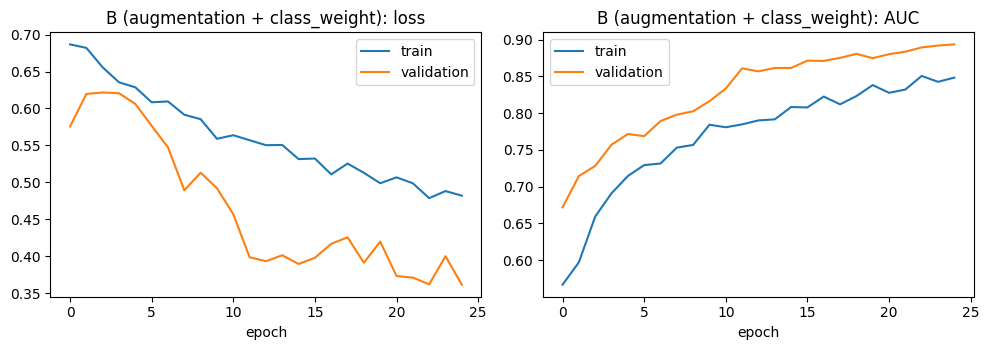

reloaded from data/ch13_cnn_aug_best.keras -> 285,569 parameters


In [10]:
if hist_b is not None:
    plot_history(hist_b, "B (augmentation + class_weight)")
    reloaded = keras.models.load_model(ckpt_path)
    print("reloaded from", ckpt_path, "->", f"{reloaded.count_params():,}", "parameters")

## 5. 遷移學習 3a：凍結的 MobileNetV2 當特徵擷取器
`keras.applications.MobileNetV2(weights="imagenet")` 會下載在 ImageNet（一般照片，不是醫學影像）上預訓練的權重（約 9 MB，存在 `~/.keras/models/`）。權重由 Keras 官方提供，授權條款以官方為準；ImageNet 本身的使用條款限非商業研究與教育用途。

做法：灰階複製成 3 個通道 → `preprocess_input` 縮放到 −1～1 → 骨幹（`include_top=False`）把每張 128×128 影像變成 4×4×1,280 的特徵圖，再平均成 **1,280 個數字** → 接第 4 章的**邏輯迴歸**。骨幹完全不訓練。

為了等一下微調時省時間，我們把骨幹切成兩段：**下段**（到倒數第二個區塊）只算一次、把結果存起來；**上段**（最後一個區塊＋最後一層卷積，共 11 層）之後再決定要不要訓練。

In [11]:
base = None
if keras is not None and data is not None:
    from keras.applications import mobilenet_v2

    def to_rgb(X_):
        return mobilenet_v2.preprocess_input(np.repeat(X_[..., None], 3, axis=-1).astype("float32"))

    Xr_tr, Xr_va, Xr_te = to_rgb(X_tr), to_rgb(X_va), to_rgb(X_te)
    keras.utils.set_random_seed(RS)
    try:
        base = keras.applications.MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights="imagenet")
        print("MobileNetV2 loaded:", f"{base.count_params():,}", "parameters,", len(base.layers), "layers")
    except Exception as e:
        print("Could not download the ImageNet weights for MobileNetV2:", repr(e))
        print("Check your internet connection (weights come from storage.googleapis.com) and re-run this cell.")
else:
    print("Skipped: Keras or the dataset is not available.")

MobileNetV2 loaded: 2,257,984 parameters, 154 layers


In [12]:
TOP_LAYERS = ["block_16_expand", "block_16_expand_BN", "block_16_expand_relu",
              "block_16_depthwise", "block_16_depthwise_BN", "block_16_depthwise_relu",
              "block_16_project", "block_16_project_BN", "Conv_1", "Conv_1_bn", "out_relu"]

def split_backbone(b):
    """Split MobileNetV2 into a lower part (computed once) and the last block (may be fine-tuned)."""
    lower = keras.Model(b.input, b.get_layer("block_15_add").output)
    z_in = keras.Input(shape=lower.output.shape[1:])
    x = z_in
    for name in TOP_LAYERS:                      # re-use the same layers (shared weights)
        x = b.get_layer(name)(x)
    return lower, keras.Model(z_in, x, name="upper")

if base is not None:
    lower, upper = split_backbone(base)
    t = time.time()
    Z_tr, Z_va, Z_te = batched(lower, Xr_tr), batched(lower, Xr_va), batched(lower, Xr_te)
    M_tr, M_va, M_te = batched(upper, Z_tr), batched(upper, Z_va), batched(upper, Z_te)  # 4x4x1280 maps
    F_tr, F_te = M_tr.mean(axis=(1, 2)), M_te.mean(axis=(1, 2))   # global average pooling -> 1,280 features
    print(f"feature extraction: {time.time() - t:.1f} s | cached lower output {Z_tr.shape} | features {F_tr.shape}")

feature extraction: 11.9 s | cached lower output (546, 4, 4, 160) | features (546, 1280)


拿 1,280 個特徵接邏輯迴歸。（`np.errstate` 只是把 macOS 上 NumPy 矩陣乘法偶爾誤報的浮點警告關掉，結果不受影響；在 Colab 上不會出現。）

In [13]:
if base is not None:
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression

    clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000))
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        clf.fit(F_tr, y_tr)
        p_c1 = clf.predict_proba(F_te)[:, 1]
    report("C1: frozen MobileNetV2 + logistic regression", y_te, p_c1)

C1: frozen MobileNetV2 + logistic regression: test AUC 0.915 (95% CI 0.860-0.962) | sensitivity 0.67 | specificity 0.96  (threshold 0.5)


## 6. 遷移學習 3b：微調（fine-tuning）最後一個區塊
分兩階段：

1. **凍結整個骨幹**，只訓練新接上的分類頭（全域平均池化 → Dropout → 1 個輸出）。骨幹不動，所以直接拿第 5 節算好的 4×4×1,280 特徵圖來訓練。
2. **解凍上段的卷積層**（批次正規化層維持凍結），用較小的學習率（`1e-4`）一起微調。批次正規化層用 `training=False` 呼叫並保持凍結，避免小批次的統計量把預訓練的平均數與變異數洗掉。

因為下段的輸出已經存好，每個 epoch 只需要算上段，CPU 也跑得動。代價是：**這種做法沒辦法同時做資料擴增**（擴增會改變輸入影像，下段就得每次重算）。想要「擴增＋解凍更多層」的完整微調，建議開 GPU。

分類頭最後一層輸出 logit（還沒經過 sigmoid），等一下 Grad-CAM 要用。

In [14]:
def make_head():
    return keras.Sequential([keras.Input(shape=(4, 4, 1280)),
                             keras.layers.GlobalAveragePooling2D(),
                             keras.layers.Dropout(0.3),
                             keras.layers.Dense(1, name="logit")], name="head")

model_c = None
if base is not None:
    keras.utils.set_random_seed(RS)
    head = make_head()
    z_in = keras.Input(shape=Z_tr.shape[1:])
    model_c = keras.Model(z_in, keras.layers.Activation("sigmoid")(head(upper(z_in, training=False))))
    es = lambda: keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)
    t = time.time()

    # stage 1: frozen backbone -> train the head only, on the cached 4x4x1280 feature maps
    head.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                 loss=keras.losses.BinaryCrossentropy(from_logits=True),
                 metrics=[keras.metrics.AUC(name="auc", from_logits=True)])
    h1 = head.fit(M_tr, y_tr, validation_data=(M_va, y_va), epochs=30, batch_size=32,
                  class_weight=class_weight, callbacks=[es()], verbose=0)
    print(f"stage 1 trainable parameters (head only): {head.count_params():,}")

    # stage 2: unfreeze the conv layers of the last block (BatchNorm stays frozen), smaller learning rate
    upper.trainable = True
    for layer in upper.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
    model_c.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss="binary_crossentropy",
                    metrics=[keras.metrics.AUC(name="auc")])
    h2 = model_c.fit(Z_tr, y_tr, validation_data=(Z_va, y_va), epochs=10, batch_size=32,
                     class_weight=class_weight, callbacks=[es()], verbose=0)
    print(f"stage 2 trainable parameters: {sum(int(np.prod(w.shape)) for w in model_c.trainable_weights):,}"
          f" of {base.count_params() + head.count_params():,}")
    print(f"fine-tuning time: {time.time() - t:.1f} s "
          f"(stage 1: {len(h1.history['loss'])} epochs, stage 2: {len(h2.history['loss'])} epochs)")
    p_c2 = batched(model_c, Z_te).ravel()
    report("C2: fine-tuned MobileNetV2 (last block)", y_te, p_c2)
else:
    print("Skipped: needs the pretrained MobileNetV2 from section 5.")

stage 1 trainable parameters (head only): 1,281


stage 2 trainable parameters: 880,321 of 2,259,265
fine-tuning time: 21.2 s (stage 1: 20 epochs, stage 2: 10 epochs)


C2: fine-tuned MobileNetV2 (last block): test AUC 0.935 (95% CI 0.887-0.973) | sensitivity 0.86 | specificity 0.88  (threshold 0.5)


### 三方對照
把所有做法的測試集結果放在一起。請注意信賴區間的寬度：測試集只有 156 張，彼此重疊的區間代表**差距未必有意義**。

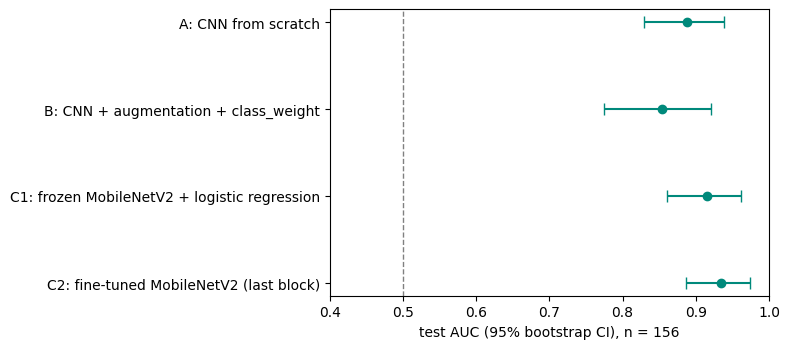

A: CNN from scratch                           AUC 0.888 (0.829-0.939)  sens 0.52  spec 0.95
B: CNN + augmentation + class_weight          AUC 0.853 (0.775-0.921)  sens 0.62  spec 0.92
C1: frozen MobileNetV2 + logistic regression  AUC 0.915 (0.860-0.962)  sens 0.67  spec 0.96
C2: fine-tuned MobileNetV2 (last block)       AUC 0.935 (0.887-0.973)  sens 0.86  spec 0.88


In [15]:
if results:
    names = list(results)
    auc = np.array([results[n]["auc"] for n in names])
    err = np.array([[results[n]["auc"] - results[n]["lo"], results[n]["hi"] - results[n]["auc"]] for n in names]).T
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(names) + 1.2))
    ax.errorbar(auc, range(len(names)), xerr=err, fmt="o", color="#00897B", capsize=4)
    ax.set_yticks(range(len(names)), names)
    ax.invert_yaxis()
    ax.axvline(0.5, color="grey", ls="--", lw=1)
    ax.set_xlim(0.4, 1.0)
    ax.set_xlabel("test AUC (95% bootstrap CI), n = 156")
    plt.tight_layout()
    plt.show()
    for n in names:
        r = results[n]
        print(f"{n:45s} AUC {r['auc']:.3f} ({r['lo']:.3f}-{r['hi']:.3f})  sens {r['sens']:.2f}  spec {r['spec']:.2f}")

## 7. Grad-CAM：模型在看哪裡？
Grad-CAM 的步驟：

1. 取骨幹最後一層卷積的特徵圖（128×128 輸入時只有 **4×4** 格、1,280 個通道）。
2. 算「惡性 logit 對每個通道的梯度」，在空間上取平均，當作每個通道的重要性權重。
3. 用權重把 1,280 張特徵圖加總、只留正值（ReLU），再放大回 128×128 疊在原圖上。

注意第 1 步：熱圖本質上只有 4×4 的解析度，看起來平滑是因為被內插放大了。

test indices shown: [0, 6, 1, 3] (last one is a misclassified case)


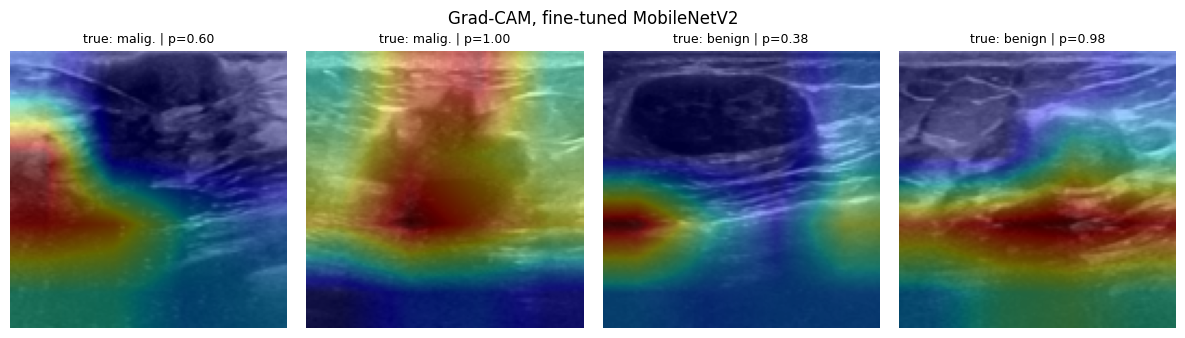

In [16]:
def grad_cam(lower_m, upper_m, head_m, x):
    """x: one preprocessed image (128, 128, 3). Returns (heatmap 128x128 in [0, 1], probability)."""
    z = lower_m(x[None], training=False)
    with tf.GradientTape() as tape:
        fmap = upper_m(z, training=False)        # (1, 4, 4, 1280)
        tape.watch(fmap)
        logit = head_m(fmap, training=False)     # (1, 1), before sigmoid
    grads = tape.gradient(logit, fmap)[0]        # (4, 4, 1280)
    channel_w = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.nn.relu(tf.reduce_sum(fmap[0] * channel_w, axis=-1))
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], (128, 128), method="bilinear")[..., 0]
    return cam.numpy(), float(tf.sigmoid(logit)[0, 0])

def show_cams(parts, indices, title):
    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3.4))
    for ax, i in zip(axes, indices):
        cam, p = grad_cam(*parts, Xr_te[i])
        ax.imshow(X_te[i], cmap="gray")
        ax.imshow(cam, cmap="jet", alpha=0.4)
        ax.set_title(f"true: {'malig.' if y_te[i] else 'benign'} | p={p:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if model_c is not None:
    pred = (p_c2 >= 0.5).astype(int)
    tp_idx = np.where((y_te == 1) & (pred == 1))[0][:2]
    tn_idx = np.where((y_te == 0) & (pred == 0))[0][:1]
    err_idx = np.where(y_te != pred)[0][:1]
    picks = np.concatenate([tp_idx, tn_idx, err_idx])
    print("test indices shown:", picks.tolist(), "(last one is a misclassified case)")
    show_cams((lower, upper, head), picks, "Grad-CAM, fine-tuned MobileNetV2")
else:
    print("Skipped: needs the fine-tuned model from section 6.")

### 健全性檢查（sanity check）：換成隨機權重，熱圖還一樣嗎？
Adebayo 等人（2018）提出：如果把模型的權重換成隨機數字，解釋方法產生的圖**應該要明顯改變**；若幾乎不變，代表那張圖反映的多半是影像本身的邊緣與亮度，而不是模型學到的東西。下面用同樣架構、但**完全沒訓練過的隨機權重**模型做一次，並計算兩組熱圖的相關係數。

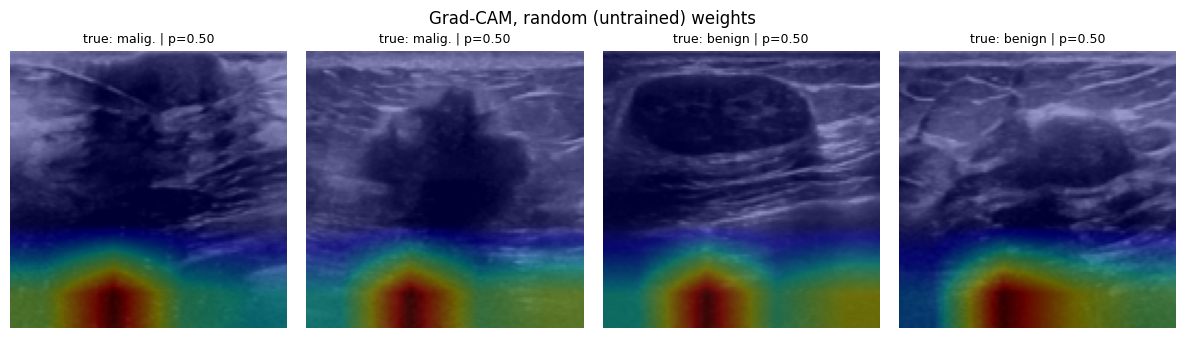

correlation between trained and random-weight heatmaps: [ 0.22 -0.77  0.16  0.23]


In [17]:
if model_c is not None:
    keras.utils.set_random_seed(RS)
    base_r = keras.applications.MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights=None)
    lower_r, upper_r = split_backbone(base_r)
    parts_r = (lower_r, upper_r, make_head())          # same architecture, random weights
    show_cams(parts_r, picks, "Grad-CAM, random (untrained) weights")
    corrs = [np.corrcoef(grad_cam(lower, upper, head, Xr_te[i])[0].ravel(),
                         grad_cam(*parts_r, Xr_te[i])[0].ravel())[0, 1] for i in picks]
    print("correlation between trained and random-weight heatmaps:", np.round(corrs, 2))

解讀提醒：

- 相關係數接近 0 或為負，代表熱圖確實隨權重改變，Grad-CAM 在這裡**通過**了這項檢查；若接近 1，就要懷疑熱圖只是在描邊。但通過檢查只代表熱圖「跟模型有關」，**不代表模型看對地方，更不代表推理正確**。
- 熱圖落在腫塊上，只說明「哪些區域對這次輸出影響最大」；熱圖落在影像邊框、文字、測量標記上，反而是抓**捷徑學習**（shortcut learning）的好線索。
- 4×4 的原始解析度很粗，小病灶的定位本來就做不準。

## 8. 動手試試

1. **擴增強度**：把 `small_cnn` 的 `RandomRotation(0.05)` 改成 `0.25`，或加上 `RandomFlip("vertical")`，B 的測試 AUC 怎麼變？上下翻轉在超音波上合理嗎？
2. **批次正規化**：B 改用 `small_cnn(augment=True, batchnorm=True, dropout=0.5)`，並把 `epochs` 加到 50。觀察驗證損失在前幾十個 epoch 的走勢——小資料、小批次時，批次正規化不一定讓訓練更穩。
3. **換骨幹**：把 MobileNetV2 換成 `keras.applications.EfficientNetB0`（它的 `preprocess_input` 不做縮放，輸入 0～255 即可；最後一層名稱也不同，先只做第 5 節的特徵擷取），比較特徵擷取＋邏輯迴歸的 AUC。
4. **拆解 B 的貢獻**：B 同時加了擴增、Dropout、`class_weight` 三件事。一次只拿掉一項，看看敏感度與特異度怎麼變（測試集很小，記得看信賴區間）。

In [18]:
print(f"total notebook run time: {time.time() - T0:.0f} s")

total notebook run time: 109 s
